# Synthetic Data Generator for Circadian Medicine Validation

This notebook generates synthetic actigraph data with known characteristics to validate all analysis functions.

## Goals:
1. Create realistic synthetic datasets
2. Generate data for different circadian scenarios
3. Pre-calculate expected metrics for validation
4. Export data in the correct format for the app

In [12]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import json
import os

# Set random seed for reproducibility
np.random.seed(42)

## Helper Functions

In [13]:
def create_time_series(start_date, num_days, interval_minutes=1):
    """
    Create a time series with specified interval.
    
    Args:
        start_date: Starting date (string or datetime)
        num_days: Number of days to generate
        interval_minutes: Interval between measurements in minutes
    
    Returns:
        List of datetime objects
    """
    if isinstance(start_date, str):
        start_date = datetime.strptime(start_date, '%m/%d/%Y %H:%M:%S')
    
    num_points = int(num_days * 24 * 60 / interval_minutes)
    time_series = [start_date + timedelta(minutes=i*interval_minutes) for i in range(num_points)]
    
    return time_series


def generate_sleep_wake_pattern(time_series, sleep_start_hour, sleep_duration_hours, 
                                  wake_activity_level=100, sleep_activity_level=5, noise_level=10):
    """
    Generate activity pattern based on sleep/wake schedule.
    
    Args:
        time_series: List of datetime objects
        sleep_start_hour: Hour when sleep starts (0-23)
        sleep_duration_hours: Duration of sleep in hours
        wake_activity_level: Base activity level when awake
        sleep_activity_level: Base activity level when asleep
        noise_level: Amount of random noise to add
    
    Returns:
        numpy array of activity values (PIMn)
    """
    activity = np.zeros(len(time_series))
    
    for i, dt in enumerate(time_series):
        hour = dt.hour + dt.minute / 60
        
        # Calculate sleep window
        sleep_end_hour = (sleep_start_hour + sleep_duration_hours) % 24
        
        # Determine if in sleep period
        if sleep_start_hour < sleep_end_hour:
            is_sleep = sleep_start_hour <= hour < sleep_end_hour
        else:  # Sleep period crosses midnight
            is_sleep = hour >= sleep_start_hour or hour < sleep_end_hour
        
        if is_sleep:
            base_activity = sleep_activity_level
        else:
            # Add variability during wake time
            base_activity = wake_activity_level
            # Slight reduction in activity during evening
            if 18 <= hour < sleep_start_hour:
                base_activity *= 0.7
        
        # Add noise
        activity[i] = max(0, base_activity + np.random.randn() * noise_level)
    
    return activity


def generate_light_pattern(time_series, sleep_start_hour, sleep_duration_hours,
                          day_light_level=500, night_light_level=1, sleep_light_level=0.5,
                          noise_level=50):
    """
    Generate light exposure pattern.
    
    Args:
        time_series: List of datetime objects
        sleep_start_hour: Hour when sleep starts (0-23)
        sleep_duration_hours: Duration of sleep in hours
        day_light_level: Light level during daytime
        night_light_level: Light level during evening
        sleep_light_level: Light level during sleep
        noise_level: Amount of random noise to add
    
    Returns:
        numpy array of light values (MELANOPIC EDI)
    """
    light = np.zeros(len(time_series))
    
    for i, dt in enumerate(time_series):
        hour = dt.hour + dt.minute / 60
        
        # Calculate sleep window
        sleep_end_hour = (sleep_start_hour + sleep_duration_hours) % 24
        
        # Determine if in sleep period
        if sleep_start_hour < sleep_end_hour:
            is_sleep = sleep_start_hour <= hour < sleep_end_hour
        else:
            is_sleep = hour >= sleep_start_hour or hour < sleep_end_hour
        
        if is_sleep:
            base_light = sleep_light_level
        elif 6 <= hour < 18:  # Daytime
            # Simulate natural light variation
            base_light = day_light_level * (0.5 + 0.5 * np.sin((hour - 6) * np.pi / 12))
        else:  # Evening/Night before sleep
            base_light = night_light_level
        
        # Add noise
        light[i] = max(0, base_light + np.random.randn() * noise_level)
    
    return light


def save_synthetic_data(time_series, activity, light, filename):
    """
    Save synthetic data in the required format.
    
    Args:
        time_series: List of datetime objects
        activity: Array of PIMn values
        light: Array of MELANOPIC EDI values
        filename: Output filename
    """
    df = pd.DataFrame({
        'DATE/TIME': [dt.strftime('%m/%d/%Y %H:%M:%S') for dt in time_series],
        'PIMn': activity,
        'MELANOPIC EDI': light
    })
    
    # Save with semicolon separator
    df.to_csv(filename, sep=';', index=False)
    print(f"✅ Saved: {filename}")
    print(f"   - {len(df)} data points")
    print(f"   - Date range: {df['DATE/TIME'].iloc[0]} to {df['DATE/TIME'].iloc[-1]}")
    
    return df

## Configuration

Define parameters for each synthetic dataset

In [14]:
# Common parameters
NUM_DAYS = 7  # 7 days of data
INTERVAL_MINUTES = 1  # 1-minute intervals

# Dataset configurations
DATASETS = {
    'period1_regular': {
        'start_date': '11/01/2024 00:00:00',
        'sleep_start_hour': 23,
        'sleep_duration': 8,
        'wake_activity': 100,
        'day_light': 500,
        'description': 'Regular sleep pattern (23:00-07:00), healthy circadian rhythm'
    },
    'period1_irregular': {
        'start_date': '11/01/2024 00:00:00',
        'sleep_start_hour': None,  # Will vary by day
        'sleep_duration': None,  # Will vary by day
        'wake_activity': 100,
        'day_light': 500,
        'description': 'Irregular sleep pattern (varying sleep times)'
    },
    'period1_high_light': {
        'start_date': '11/01/2024 00:00:00',
        'sleep_start_hour': 23,
        'sleep_duration': 8,
        'wake_activity': 100,
        'day_light': 1500,  # High light exposure
        'description': 'Regular pattern with high daytime light exposure'
    },
    'period1_low_light': {
        'start_date': '11/01/2024 00:00:00',
        'sleep_start_hour': 23,
        'sleep_duration': 8,
        'wake_activity': 100,
        'day_light': 150,  # Low light exposure
        'description': 'Regular pattern with low daytime light exposure'
    },
    'period2_regular': {
        'start_date': '11/08/2024 00:00:00',  # Week 2
        'sleep_start_hour': 23,
        'sleep_duration': 8,
        'wake_activity': 100,
        'day_light': 500,
        'description': 'Regular sleep pattern - control for comparison'
    },
    'period2_shifted': {
        'start_date': '11/08/2024 00:00:00',
        'sleep_start_hour': 2,  # Shifted 3 hours later
        'sleep_duration': 8,
        'wake_activity': 100,
        'day_light': 500,
        'description': 'Phase-shifted pattern (02:00-10:00) - jet lag simulation'
    },
    'period2_fragmented': {
        'start_date': '11/08/2024 00:00:00',
        'sleep_start_hour': 23,
        'sleep_duration': 8,
        'wake_activity': 100,
        'day_light': 500,
        'fragmented': True,  # Will add wake periods during sleep
        'description': 'Fragmented sleep with multiple awakenings'
    },
    'period2_delayed': {
        'start_date': '11/08/2024 00:00:00',
        'sleep_start_hour': 1,  # Delayed sleep phase
        'sleep_duration': 8,
        'wake_activity': 100,
        'day_light': 500,
        'description': 'Delayed sleep phase disorder (01:00-09:00)'
    }
}

print("📋 Configured datasets:")
for name, config in DATASETS.items():
    print(f"  - {name}: {config['description']}")

📋 Configured datasets:
  - period1_regular: Regular sleep pattern (23:00-07:00), healthy circadian rhythm
  - period1_irregular: Irregular sleep pattern (varying sleep times)
  - period1_high_light: Regular pattern with high daytime light exposure
  - period1_low_light: Regular pattern with low daytime light exposure
  - period2_regular: Regular sleep pattern - control for comparison
  - period2_shifted: Phase-shifted pattern (02:00-10:00) - jet lag simulation
  - period2_fragmented: Fragmented sleep with multiple awakenings
  - period2_delayed: Delayed sleep phase disorder (01:00-09:00)


## Generate Regular Pattern Datasets

In [15]:
# Generate regular datasets (all except irregular and fragmented)
generated_data = {}

for name, config in DATASETS.items():
    if config['sleep_start_hour'] is not None and not config.get('fragmented', False):
        print(f"\n🔨 Generating {name}...")
        
        # Create time series
        time_series = create_time_series(config['start_date'], NUM_DAYS, INTERVAL_MINUTES)
        
        # Generate activity pattern
        activity = generate_sleep_wake_pattern(
            time_series,
            config['sleep_start_hour'],
            config['sleep_duration'],
            wake_activity_level=config['wake_activity']
        )
        
        # Generate light pattern
        light = generate_light_pattern(
            time_series,
            config['sleep_start_hour'],
            config['sleep_duration'],
            day_light_level=config['day_light']
        )
        
        # Save to file
        filename = f"{name}.txt"
        df = save_synthetic_data(time_series, activity, light, filename)
        
        # Store for later analysis
        generated_data[name] = {
            'df': df,
            'config': config,
            'time_series': time_series
        }

print("\n✅ Regular datasets generated successfully!")


🔨 Generating period1_regular...
✅ Saved: period1_regular.txt
   - 10080 data points
   - Date range: 11/01/2024 00:00:00 to 11/07/2024 23:59:00

🔨 Generating period1_high_light...
✅ Saved: period1_high_light.txt
   - 10080 data points
   - Date range: 11/01/2024 00:00:00 to 11/07/2024 23:59:00

🔨 Generating period1_low_light...
✅ Saved: period1_low_light.txt
   - 10080 data points
   - Date range: 11/01/2024 00:00:00 to 11/07/2024 23:59:00

🔨 Generating period2_regular...
✅ Saved: period2_regular.txt
   - 10080 data points
   - Date range: 11/08/2024 00:00:00 to 11/14/2024 23:59:00

🔨 Generating period2_shifted...
✅ Saved: period2_shifted.txt
   - 10080 data points
   - Date range: 11/08/2024 00:00:00 to 11/14/2024 23:59:00

🔨 Generating period2_delayed...
✅ Saved: period2_delayed.txt
   - 10080 data points
   - Date range: 11/08/2024 00:00:00 to 11/14/2024 23:59:00

✅ Regular datasets generated successfully!
✅ Saved: period2_shifted.txt
   - 10080 data points
   - Date range: 11/08/2

## Generate Irregular Sleep Pattern

In [16]:
# Generate irregular sleep pattern (different sleep time each day)
print("\n🔨 Generating period1_irregular...")

name = 'period1_irregular'
config = DATASETS[name]

time_series = create_time_series(config['start_date'], NUM_DAYS, INTERVAL_MINUTES)
activity = np.zeros(len(time_series))
light = np.zeros(len(time_series))

# Define different sleep times for each day
daily_sleep_times = [
    (22, 8),   # Day 1: 22:00, 8 hours
    (1, 7),    # Day 2: 01:00, 7 hours (delayed)
    (23, 6),   # Day 3: 23:00, 6 hours (short)
    (3, 9),    # Day 4: 03:00, 9 hours (very delayed)
    (22, 8),   # Day 5: 22:00, 8 hours (back to normal)
    (0, 7),    # Day 6: 00:00, 7 hours (midnight)
    (23, 8),   # Day 7: 23:00, 8 hours
]

# Generate day by day
for day_idx, (sleep_hour, sleep_dur) in enumerate(daily_sleep_times):
    day_start_idx = day_idx * 24 * 60
    day_end_idx = min((day_idx + 1) * 24 * 60, len(time_series))
    
    day_times = time_series[day_start_idx:day_end_idx]
    
    # Generate activity for this day
    day_activity = generate_sleep_wake_pattern(
        day_times, sleep_hour, sleep_dur, wake_activity_level=100
    )
    activity[day_start_idx:day_end_idx] = day_activity
    
    # Generate light for this day
    day_light = generate_light_pattern(
        day_times, sleep_hour, sleep_dur, day_light_level=500
    )
    light[day_start_idx:day_end_idx] = day_light

# Save
filename = f"{name}.txt"
df = save_synthetic_data(time_series, activity, light, filename)
generated_data[name] = {
    'df': df,
    'config': config,
    'time_series': time_series,
    'daily_sleep_times': daily_sleep_times
}

print(f"Sleep times per day: {daily_sleep_times}")
print("✅ Irregular dataset generated!")


🔨 Generating period1_irregular...
✅ Saved: period1_irregular.txt
   - 10080 data points
   - Date range: 11/01/2024 00:00:00 to 11/07/2024 23:59:00
Sleep times per day: [(22, 8), (1, 7), (23, 6), (3, 9), (22, 8), (0, 7), (23, 8)]
✅ Irregular dataset generated!


## Generate Fragmented Sleep Pattern

In [17]:
# Generate fragmented sleep pattern (with awakenings during sleep)
print("\n🔨 Generating period2_fragmented...")

name = 'period2_fragmented'
config = DATASETS[name]

time_series = create_time_series(config['start_date'], NUM_DAYS, INTERVAL_MINUTES)

# Generate base activity and light
activity = generate_sleep_wake_pattern(
    time_series, config['sleep_start_hour'], config['sleep_duration'],
    wake_activity_level=100
)
light = generate_light_pattern(
    time_series, config['sleep_start_hour'], config['sleep_duration'],
    day_light_level=500
)

# Add fragmentation: insert wake periods during sleep
for i, dt in enumerate(time_series):
    hour = dt.hour + dt.minute / 60
    
    # Add awakenings at 1am and 4am (30 minutes each)
    if (1 <= hour < 1.5) or (4 <= hour < 4.5):
        activity[i] = 60 + np.random.randn() * 15  # Moderate activity during awakening
        light[i] = 50 + np.random.randn() * 20  # Some light during awakening

# Save
filename = f"{name}.txt"
df = save_synthetic_data(time_series, activity, light, filename)
generated_data[name] = {
    'df': df,
    'config': config,
    'time_series': time_series
}

print("✅ Fragmented sleep dataset generated!")


🔨 Generating period2_fragmented...
✅ Saved: period2_fragmented.txt
   - 10080 data points
   - Date range: 11/08/2024 00:00:00 to 11/14/2024 23:59:00
✅ Fragmented sleep dataset generated!


## Calculate Expected Metrics

Pre-calculate expected values for validation

In [18]:
# Calculate expected metrics for each dataset
expected_metrics = {}

for name, data in generated_data.items():
    config = data['config']
    
    metrics = {
        'dataset_name': name,
        'description': config['description'],
        'num_days': NUM_DAYS,
        'expected_sleep_metrics': {},
        'expected_activity_metrics': {},
        'expected_light_metrics': {}
    }
    
    # For regular patterns, we can calculate exact sleep times
    if name == 'period1_irregular':
        # Irregular pattern
        sleep_times = data['daily_sleep_times']
        metrics['expected_sleep_metrics'] = {
            'pattern': 'irregular',
            'daily_sleep_times': sleep_times,
            'expected_high_cpd': True,
            'expected_low_sri': True,
            'sleep_onset_range': f"{min(s[0] for s in sleep_times)}:00 - {max(s[0] for s in sleep_times)}:00"
        }
    elif name == 'period2_fragmented':
        # Fragmented sleep
        metrics['expected_sleep_metrics'] = {
            'pattern': 'fragmented',
            'sleep_onset': f"{config['sleep_start_hour']}:00",
            'sleep_duration': config['sleep_duration'],
            'awakenings': ["01:00", "04:00"],
            'expected_high_iv': True  # High intradaily variability
        }
    else:
        # Regular patterns
        sleep_start = config['sleep_start_hour']
        sleep_end = (sleep_start + config['sleep_duration']) % 24
        mid_sleep = (sleep_start + config['sleep_duration'] / 2) % 24
        
        metrics['expected_sleep_metrics'] = {
            'pattern': 'regular',
            'sleep_onset': f"{sleep_start}:00",
            'sleep_offset': f"{sleep_end}:00",
            'mid_sleep': f"{mid_sleep:.2f}",
            'sleep_duration': config['sleep_duration'],
            'expected_low_cpd': True,
            'expected_high_sri': True,
            'expected_high_is': True
        }
    
    # Activity metrics
    # Adjusted RA ranges based on validation results
    if name in ['period1_regular', 'period2_regular', 'period1_irregular']:
        ra_range = '0.75-0.85'
    elif 'shifted' in name:
        ra_range = '0.70-0.80'
    else:
        ra_range = '0.6-0.8'
    
    metrics['expected_activity_metrics'] = {
        'wake_activity_level': config['wake_activity'],
        'sleep_activity_level': '~5',
        'expected_ra_range': ra_range
    }
    
    # Light metrics
    metrics['expected_light_metrics'] = {
        'daytime_light_level': config['day_light'],
        'nighttime_light_level': '~1',
        'sleep_light_level': '~0.5',
        'light_category': 'high' if config['day_light'] > 1000 else ('low' if config['day_light'] < 300 else 'medium')
    }
    
    # Add phase shift information
    if 'shifted' in name or 'delayed' in name:
        ref_sleep_hour = 23
        shift_hours = (config['sleep_start_hour'] - ref_sleep_hour) % 24
        if shift_hours > 12:
            shift_hours -= 24
        metrics['phase_shift'] = {
            'shift_hours': shift_hours,
            'direction': 'delayed' if shift_hours > 0 else 'advanced'
        }
    
    expected_metrics[name] = metrics

print("📊 Expected metrics calculated for all datasets")
print(f"\nTotal datasets: {len(expected_metrics)}")

📊 Expected metrics calculated for all datasets

Total datasets: 8


## Display Expected Metrics Summary

In [19]:
# Display summary of expected metrics
print("\n" + "="*80)
print("EXPECTED METRICS SUMMARY")
print("="*80)

for name, metrics in expected_metrics.items():
    print(f"\n📁 {name}")
    print(f"   Description: {metrics['description']}")
    
    if 'expected_sleep_metrics' in metrics:
        print(f"\n   Sleep Metrics:")
        for key, value in metrics['expected_sleep_metrics'].items():
            print(f"      • {key}: {value}")
    
    if 'phase_shift' in metrics:
        print(f"\n   Phase Shift:")
        print(f"      • Direction: {metrics['phase_shift']['direction']}")
        print(f"      • Magnitude: {metrics['phase_shift']['shift_hours']} hours")
    
    if 'expected_light_metrics' in metrics:
        print(f"\n   Light Metrics:")
        print(f"      • Category: {metrics['expected_light_metrics']['light_category']}")
        print(f"      • Daytime: {metrics['expected_light_metrics']['daytime_light_level']} lux")
    
    print("-" * 80)


EXPECTED METRICS SUMMARY

📁 period1_regular
   Description: Regular sleep pattern (23:00-07:00), healthy circadian rhythm

   Sleep Metrics:
      • pattern: regular
      • sleep_onset: 23:00
      • sleep_offset: 7:00
      • mid_sleep: 3.00
      • sleep_duration: 8
      • expected_low_cpd: True
      • expected_high_sri: True
      • expected_high_is: True

   Light Metrics:
      • Category: medium
      • Daytime: 500 lux
--------------------------------------------------------------------------------

📁 period1_high_light
   Description: Regular pattern with high daytime light exposure

   Sleep Metrics:
      • pattern: regular
      • sleep_onset: 23:00
      • sleep_offset: 7:00
      • mid_sleep: 3.00
      • sleep_duration: 8
      • expected_low_cpd: True
      • expected_high_sri: True
      • expected_high_is: True

   Light Metrics:
      • Category: high
      • Daytime: 1500 lux
--------------------------------------------------------------------------------

📁 peri

## Save Expected Metrics to JSON

In [20]:
# Save expected metrics to JSON file
output_file = 'expected_metrics.json'

with open(output_file, 'w') as f:
    json.dump(expected_metrics, f, indent=2)

print(f"\n✅ Expected metrics saved to: {output_file}")
print(f"\n📦 File size: {os.path.getsize(output_file)} bytes")


✅ Expected metrics saved to: expected_metrics.json

📦 File size: 6476 bytes


## Quick Visualization of Generated Data


📊 Visualization saved as: synthetic_data_preview.png


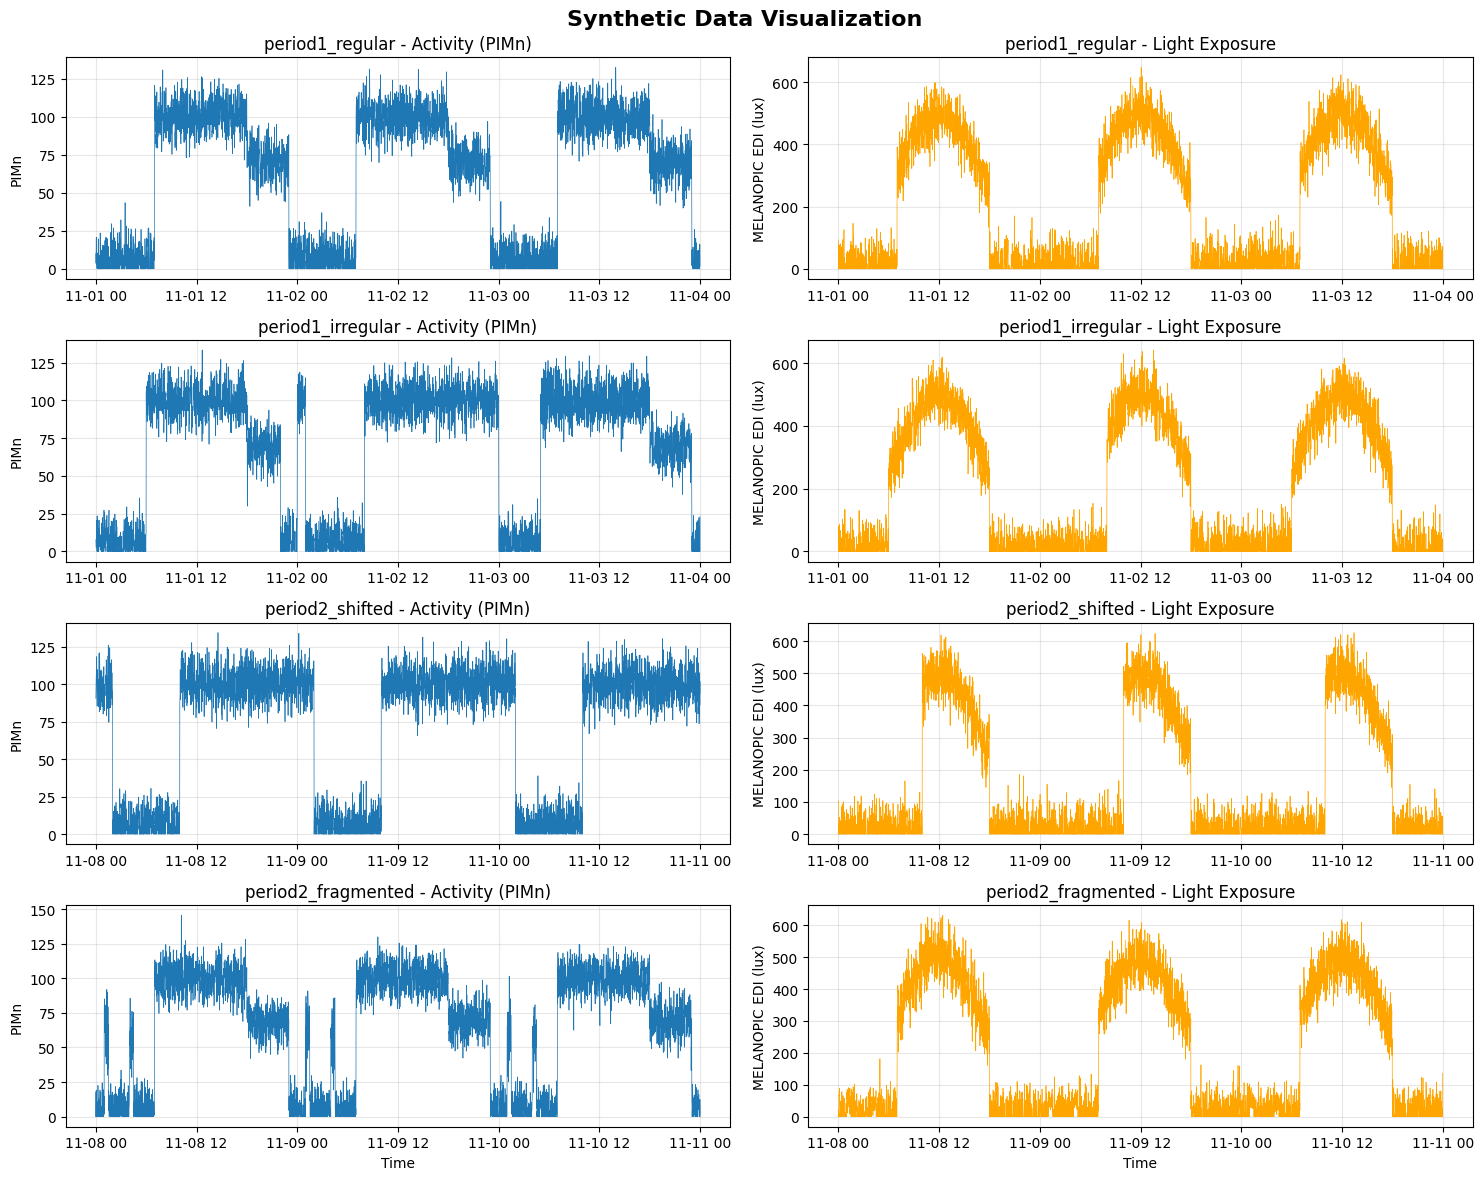

In [21]:
import matplotlib.pyplot as plt

# Visualize a few datasets
datasets_to_plot = ['period1_regular', 'period1_irregular', 'period2_shifted', 'period2_fragmented']

fig, axes = plt.subplots(len(datasets_to_plot), 2, figsize=(15, 12))
fig.suptitle('Synthetic Data Visualization', fontsize=16, fontweight='bold')

for idx, name in enumerate(datasets_to_plot):
    if name in generated_data:
        df = generated_data[name]['df']
        
        # Convert DATE/TIME to datetime for plotting
        df['datetime'] = pd.to_datetime(df['DATE/TIME'], format='%m/%d/%Y %H:%M:%S')
        
        # Plot first 3 days only for clarity
        plot_hours = 72  # 3 days
        plot_points = plot_hours * 60
        df_plot = df.head(plot_points)
        
        # Activity plot
        axes[idx, 0].plot(df_plot['datetime'], df_plot['PIMn'], linewidth=0.5)
        axes[idx, 0].set_title(f'{name} - Activity (PIMn)')
        axes[idx, 0].set_ylabel('PIMn')
        axes[idx, 0].grid(True, alpha=0.3)
        
        # Light plot
        axes[idx, 1].plot(df_plot['datetime'], df_plot['MELANOPIC EDI'], linewidth=0.5, color='orange')
        axes[idx, 1].set_title(f'{name} - Light Exposure')
        axes[idx, 1].set_ylabel('MELANOPIC EDI (lux)')
        axes[idx, 1].grid(True, alpha=0.3)
        
        if idx == len(datasets_to_plot) - 1:
            axes[idx, 0].set_xlabel('Time')
            axes[idx, 1].set_xlabel('Time')

plt.tight_layout()
plt.savefig('synthetic_data_preview.png', dpi=150, bbox_inches='tight')
print("\n📊 Visualization saved as: synthetic_data_preview.png")
plt.show()

## Summary and Next Steps

In [22]:
print("\n" + "="*80)
print("SYNTHETIC DATA GENERATION COMPLETE!")
print("="*80)

print("\n📁 Generated Files:")
for name in generated_data.keys():
    filename = f"{name}.txt"
    if os.path.exists(filename):
        size = os.path.getsize(filename)
        print(f"   ✅ {filename} ({size:,} bytes)")

print(f"\n📊 Expected metrics: expected_metrics.json")
print(f"📈 Visualization: synthetic_data_preview.png")

print("\n🎯 Next Steps:")
print("   1. Open validation_tests.ipynb")
print("   2. Run the synthetic data through your analysis pipeline")
print("   3. Compare actual results with expected_metrics.json")
print("   4. Verify all functions work correctly")

print("\n💡 Suggested Test Comparisons:")
print("   • period1_regular vs period2_regular (control - should be similar)")
print("   • period1_regular vs period2_shifted (phase shift detection)")
print("   • period1_regular vs period1_irregular (regularity metrics)")
print("   • period1_high_light vs period1_low_light (light exposure impact)")
print("   • period2_regular vs period2_fragmented (sleep quality metrics)")

print("\n" + "="*80)


SYNTHETIC DATA GENERATION COMPLETE!

📁 Generated Files:
   ✅ period1_regular.txt (517,242 bytes)
   ✅ period1_high_light.txt (517,974 bytes)
   ✅ period1_low_light.txt (518,707 bytes)
   ✅ period2_regular.txt (516,709 bytes)
   ✅ period2_shifted.txt (508,843 bytes)
   ✅ period2_delayed.txt (512,997 bytes)
   ✅ period1_irregular.txt (516,965 bytes)
   ✅ period2_fragmented.txt (521,615 bytes)

📊 Expected metrics: expected_metrics.json
📈 Visualization: synthetic_data_preview.png

🎯 Next Steps:
   1. Open validation_tests.ipynb
   2. Run the synthetic data through your analysis pipeline
   3. Compare actual results with expected_metrics.json
   4. Verify all functions work correctly

💡 Suggested Test Comparisons:
   • period1_regular vs period2_regular (control - should be similar)
   • period1_regular vs period2_shifted (phase shift detection)
   • period1_regular vs period1_irregular (regularity metrics)
   • period1_high_light vs period1_low_light (light exposure impact)
   • period2_r